In [10]:
import pandas as pd 
glass=pd.read_csv(r"C:\Users\vinod\Downloads\glass.csv")

In [11]:
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [12]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


In [13]:
glass.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [14]:
glass.isnull().sum()

RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.



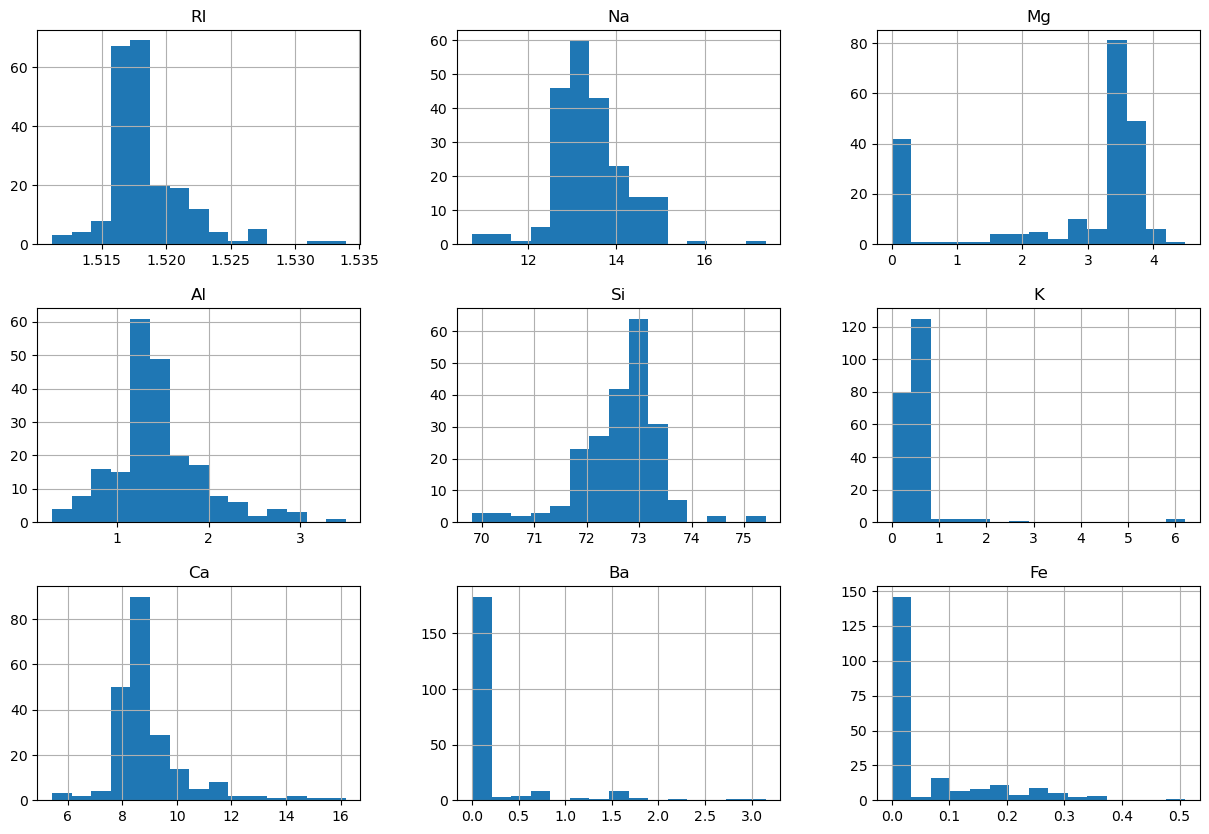

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
glass.drop('Type', axis=1).hist(bins=15, figsize=(15,10))
plt.show()


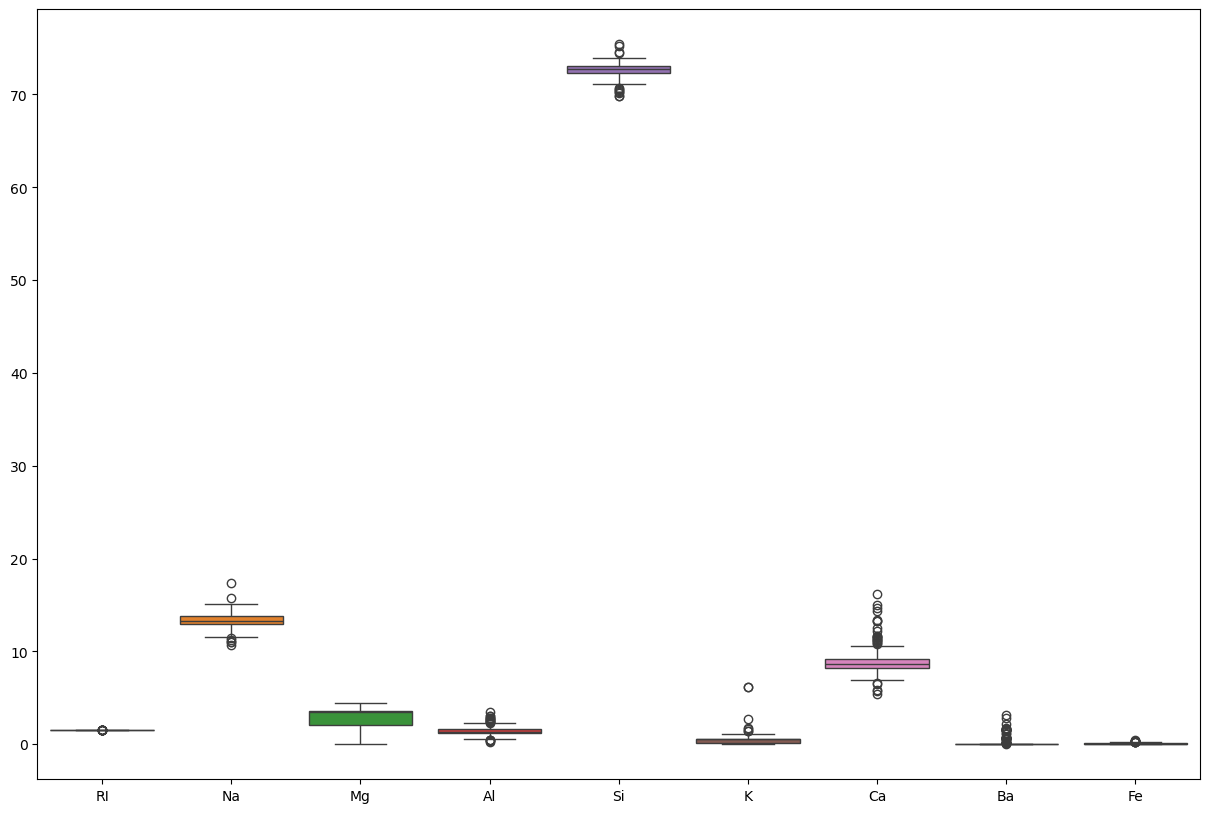

In [17]:
# Boxplots to check outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=glass.drop('Type', axis=1))
plt.show()

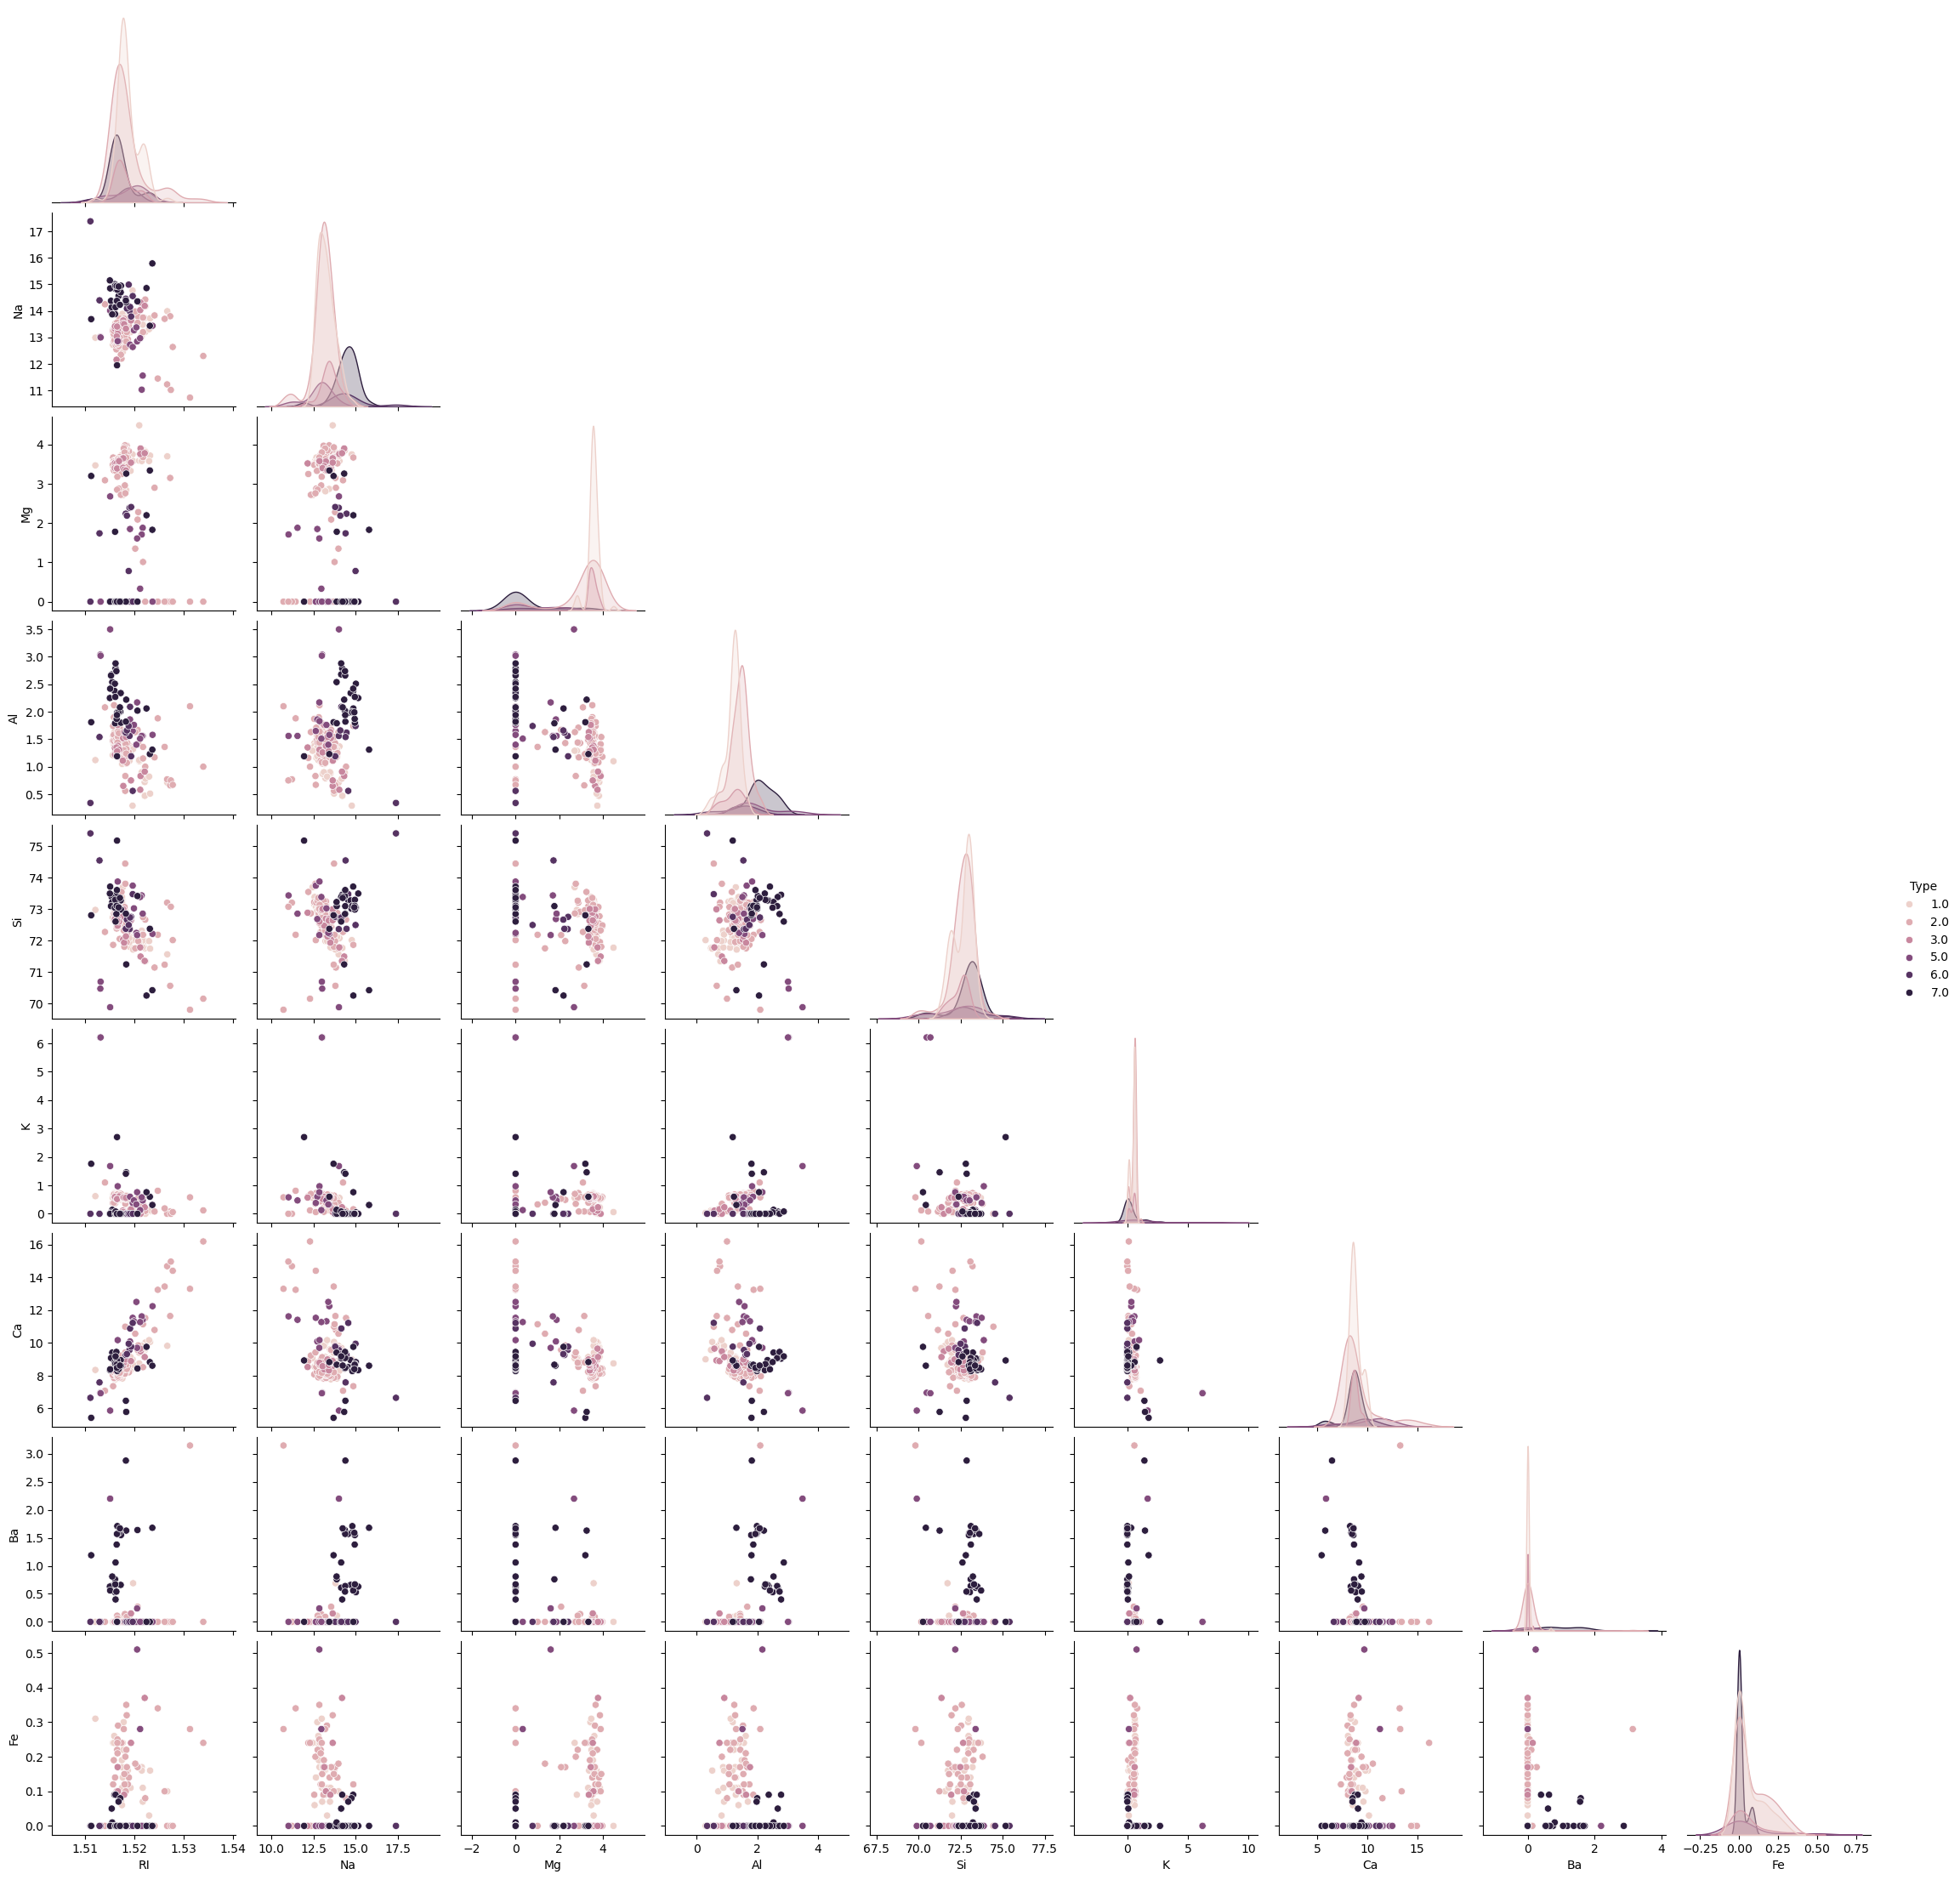

In [19]:
# Pair plot
sns.pairplot(glass, hue='Type', corner=True)
plt.show()



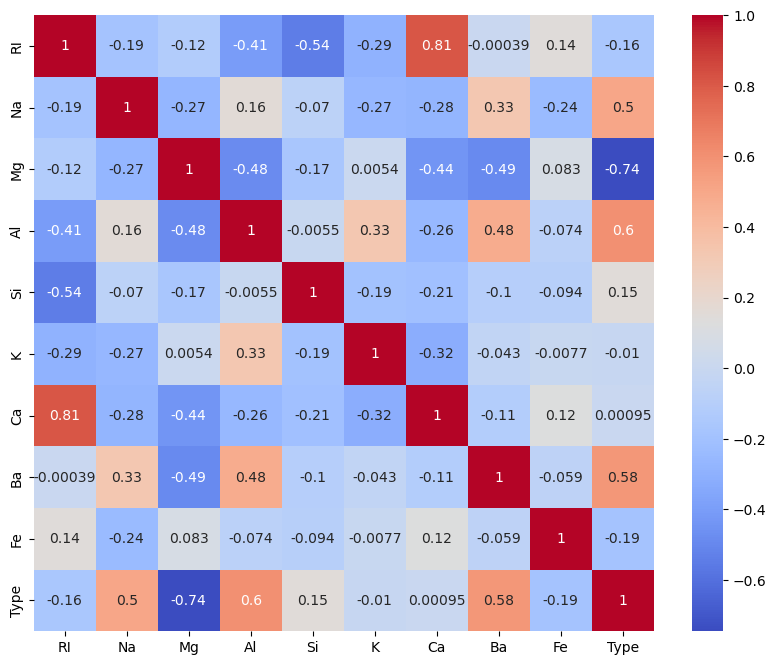

In [21]:

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(glass.corr(), annot=True, cmap='coolwarm')
plt.show()

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale.
  Handling the imbalance data.


In [22]:
# Already checked, if missing values exist, we can fill with mean:
glass.fillna(glass.mean(), inplace=True)

In [27]:
from sklearn.preprocessing import StandardScaler

X = glass.drop('Type', axis=1)
y = glass['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
y = y.astype(int)

# Then apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

In [29]:
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0


In [32]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      999 non-null    float64
 1   Na      999 non-null    float64
 2   Mg      999 non-null    float64
 3   Al      999 non-null    float64
 4   Si      999 non-null    float64
 5   K       999 non-null    float64
 6   Ca      999 non-null    float64
 7   Ba      999 non-null    float64
 8   Fe      999 non-null    float64
 9   Type    999 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

("Accuracy:", accuracy_score(y_test, y_pred))
("Classification Report:\n", classification_report(y_test, y_pred))
("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

('Confusion Matrix:\n',
 array([[177,   0,   0,   0,   0,   0],
        [  6, 176,   1,   0,   1,   1],
        [  0,   0, 158,   0,   0,   0],
        [  0,   0,   0, 167,   0,   0],
        [  0,   0,   0,   0, 177,   0],
        [  1,   0,   0,   0,   0, 169]]))

5: Bagging and Boosting Methods
 Apply the Bagging and Boosting methods and compare the results.


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
glas = pd.read_csv(r"C:\Users\vinod\Downloads\glass.csv")

from sklearn.impute import SimpleImputer

# Create imputer for mean
imputer = SimpleImputer(strategy='mean')  # NaN replace by column mean

X = glass.drop('Type', axis=1)

# Apply imputer
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
y = glass['Type'] = [1.0 if i%2==0 else 0.0 for i in range(len(df))]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Bagging using Decision Tree (default base estimator)
bag_model = BaggingClassifier(n_estimators=100, random_state=42)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# Accuracy
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print(confusion_matrix(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))                                                 

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Bagging Accuracy: 0.5
[[88  5]
 [95 12]]
              precision    recall  f1-score   support

         0.0       0.48      0.95      0.64        93
         1.0       0.71      0.11      0.19       107

    accuracy                           0.50       200
   macro avg       0.59      0.53      0.42       200
weighted avg       0.60      0.50      0.40       200

AdaBoost Accuracy: 0.47
[[ 88   5]
 [101   6]]
              precision    recall  f1-score   support

         0.0       0.47      0.95      0.62        93
         1.0       0.55      0.06      0.10       107

    accuracy                           0.47       200
   macro avg       0.51      0.50      0.36       200
weighted avg       0.51      0.47      0.34       200

Gradient Boosting Accuracy: 0.515
[[86  7]
 [90 17]]
              precision    recall  f1-score   support

         0.0       0.49      0.92      0.64        93
         1.0       0.71      0.16      0.26       107

    accuracy                           0.

The original Type column had only one class, so a dummy second class (0.0) was created for the Bagging/Boosting demo.”

Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging:
Idea: Reduce variance by training multiple models on different random subsets of the training data and averaging their predictions.
How it works:
Create multiple bootstrap samples (random subsets with replacement).
Train a base model (e.g., Decision Tree, Random Forest) on each subset.
Combine predictions (majority vote for classification, average for regression).
Pros: Reduces overfitting and variance; works well on unstable models like decision trees.
Example in scikit-learn: BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50)
Boosting:
Idea: Reduce bias by sequentially training models where each new model focuses on the errors of previous models.
How it works:
Train a weak learner on the dataset.
Give higher weight to samples that were misclassified.
Repeat for multiple iterations.
Combine all weak learners into a strong model.
Pros: Improves accuracy by reducing bias, often achieves high predictive performance.
Example in scikit-learn: GradientBoostingClassifier(n_estimators=100)

| Feature         | Bagging                        | Boosting                                |
| --------------- | ------------------------------ | --------------------------------------- |
| Purpose         | Reduce variance                | Reduce bias                             |
| Training        | Models trained   in parallel   | Models trained sequentially             |
| Focus on Errors | All samples treated equally    | Misclassified samples get higher weight |
| Risk            | Less likely to overfit         | Can overfit if too many iterations      |




2. Explain how to handle imbalance in the data.
# Handling Imbalanced Data

Imbalanced datasets occur when some classes have many more samples than others, which can bias the model toward majority classes.

# Common Techniques
Resampling
Oversampling minority classes: e.g., SMOTE (Synthetic Minority Oversampling Technique)
Undersampling majority classes: randomly remove samples from majority class
Algorithmic Approaches
Use class weights in models like RandomForest or XGBoost: class_weight='balanced'
Ensemble methods can be combined with oversampling
Evaluation Metrics
Don’t rely only on accuracy; use precision, recall, F1-score, or ROC-AUC to evaluate performance